<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

Воспользуемся RegexpTokenizer, чтобы убрать знаки препинания.

In [6]:
tokenizer = RegexpTokenizer(r'\w+')

In [7]:
sentences = []
s = 0
word_threshold = 32
for example in tqdm(dataset['train']['text']):
    sentences += [sentence for sentence in sent_tokenize(example) if len(tokenizer.tokenize(sentence)) < word_threshold]


  0%|          | 0/25000 [00:00<?, ?it/s]

In [8]:
print("Всего предложений:", len(sentences))

Всего предложений: 216118


Посчитаем для каждого слова его встречаемость.

In [9]:
words = Counter()
stop_words = set(stopwords.words('english'))

for sentence in sentences:
    for word in tokenizer.tokenize(sentence):
        words[word] += 1

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [10]:
vocab_size = 40000

# Наполнение словаря
vocab = set([word[0] for word in words.most_common(vocab_size)])
for elem in ['<unk>', '<bos>', '<eos>', '<pad>']:
    vocab.add(elem)

In [11]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [12]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [13]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [14]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in tokenizer.tokenize(self.data[idx])]
        tokenized_sentence += [self.eos_id]
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [15]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [16]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [17]:
import math
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(loss.item())

    perplexity = sum(perplexity) / len(perplexity)
    perplexity = math.exp(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [18]:
!pip install -U lrcurve

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.7 MB/s eta 0:00:00


In [19]:
from lrcurve import PlotLearningCurve

In [20]:
def train_model(model, optimizer, criterion, num_epoch):
    plot = PlotLearningCurve(
        mappings = {
        'loss': { 'line': 'train', 'facet': 'loss' },
        'perplexities': { 'line': 'train', 'facet': 'perplexity' },
    },
    facet_config = {
        'loss': { 'name': 'loss', 'limit': [0, None], 'scale': 'linear' },
        'perplexity': { 'name': 'perplexity', 'limit': [0, None], 'scale': 'linear' }
    }, height=700, width=1000)
    losses = []
    perplexities = []
    with plot:
        for epoch in range(num_epoch):
            epoch_losses = []
            model.train()
            for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
                optimizer.zero_grad()
                logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
                loss = criterion(logits, batch['target_ids'].flatten())
                loss.backward()
                optimizer.step()

                epoch_losses.append(loss.item())

            losses.append(sum(epoch_losses) / len(epoch_losses))
            perplexities.append(evaluate(model, criterion, eval_dataloader))
            plot.append(epoch, {'loss': losses[-1], 'perplexities': perplexities[-1]})
            plot.draw()
    return model, losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её. Возьмём базовую архитектуру из семинара, и проведёт 2 опыта в эксперименте - hidden_dim=256, 10 эпох и hidden_dim=512, 20 эпох

#### Опыт 1

In [53]:
class LanguageModel1(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [54]:
model1_1 = LanguageModel1(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion1_1 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer1_1 = torch.optim.Adam(model1_1.parameters())

In [55]:
model1_1, losses1_1, perplexities1_1 = train_model(model1_1, optimizer1_1, criterion1_1, 10)

Training epoch 0::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1351 [00:00<?, ?it/s]

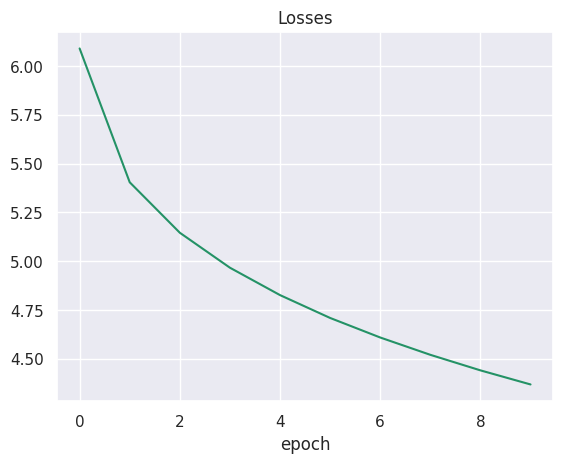

In [56]:
plt.plot(np.arange(len(losses1_1)), losses1_1)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

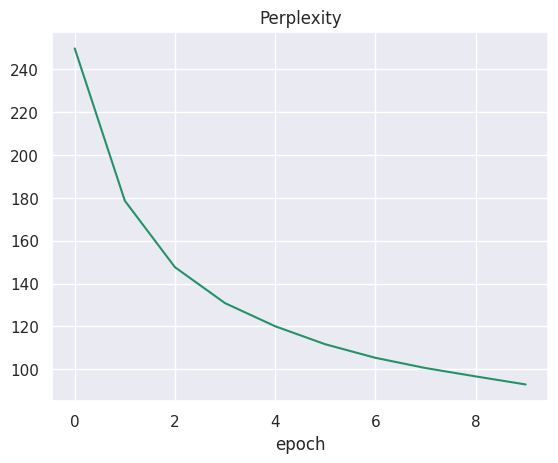

In [57]:
plt.plot(np.arange(len(perplexities1_1)), perplexities1_1)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [58]:
evaluate(model1_1, criterion1_1, test_dataloader)

92.99502983019221

#### Опыт 2

In [67]:
model1_2 = LanguageModel1(hidden_dim=512, vocab_size=len(vocab)).to(device)
criterion1_2 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer1_2 = torch.optim.Adam(model1_2.parameters())

In [68]:
model1_2, losses1_2, perplexities1_2 = train_model(model1_2, optimizer1_2, criterion1_2, 20)

Training epoch 0::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1351 [00:00<?, ?it/s]

...

Training epoch 15::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 16::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 17::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 18::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 19::   0%|          | 0/1351 [00:00<?, ?it/s]

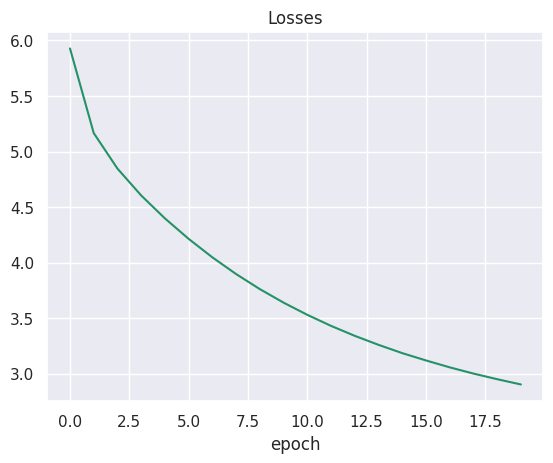

In [69]:
plt.plot(np.arange(len(losses1_2)), losses1_2)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

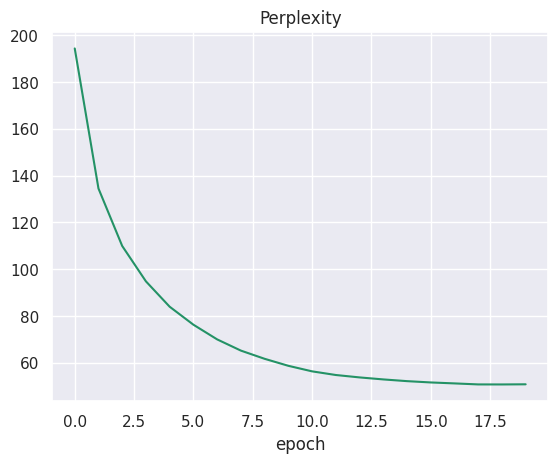

In [70]:
plt.plot(np.arange(len(perplexities1_2)), perplexities1_2)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [71]:
evaluate(model1_2, criterion1_2, test_dataloader)

51.16615282358614

### Второй эксперимент (2 балла)

Уберём из словаря стоп-слова, добавим num_layers и layer_norm.

In [21]:
words1 = Counter()
stop_words = set(stopwords.words('english'))

for sentence in sentences:
    for word in tokenizer.tokenize(sentence):
        if word not in stop_words:
          words1[word] += 1

In [22]:
vocab_size = 40000

# Наполнение словаря
vocab1 = set([word[0] for word in words1.most_common(vocab_size)])
for elem in ['<unk>', '<bos>', '<eos>', '<pad>']:
    vocab1.add(elem)

In [23]:
class LanguageModel2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True)
        self.ln_rnn = nn.LayerNorm(hidden_dim)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.ln_linear = nn.LayerNorm(hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.ln_rnn(output)
        output = self.dropout(self.linear(self.non_lin(output)))
        output = self.ln_linear(output)
        projection = self.projection(self.non_lin(output))
        return projection

In [24]:
model2_1 = LanguageModel2(hidden_dim=512, vocab_size=len(vocab1)).to(device)
criterion2_1 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer2_1 = torch.optim.Adam(model2_1.parameters())

In [25]:
model2_1, losses2_1, perplexities2_1 = train_model(model2_1, optimizer2_1, criterion2_1, 20)

Training epoch 0::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1351 [00:00<?, ?it/s]

...

Training epoch 15::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 16::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 17::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 18::   0%|          | 0/1351 [00:00<?, ?it/s]

Training epoch 19::   0%|          | 0/1351 [00:00<?, ?it/s]

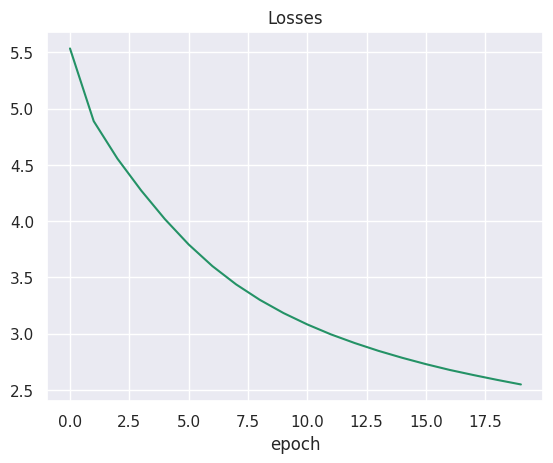

In [26]:
plt.plot(np.arange(len(losses2_1)), losses2_1)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

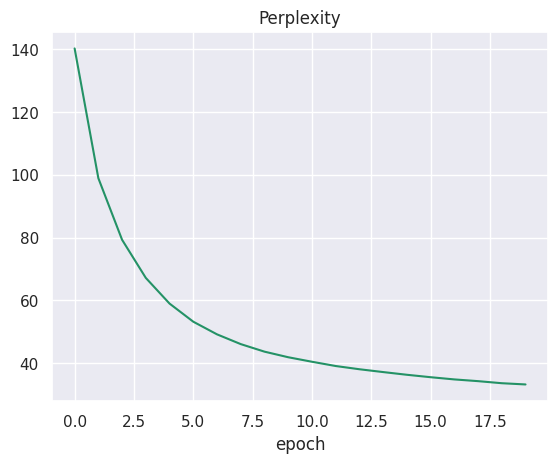

In [27]:
plt.plot(np.arange(len(perplexities2_1)), perplexities2_1)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [28]:
evaluate(model2_1, criterion2_1, test_dataloader)

33.21612171192815

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

Базовая модель состоящая из одного слоя LSTM показала перплексию 92.99 для обучения на 10 эпохах. На 20 эпохах перплексия уменьшилась до 51.16. Затем на 20 эпохах была обучена новая модель. В новой модели количество эпох также 20, но был добавлен второй слой LSTM, удалены стоп слова из словаря и добавлена Layer Normalisation. Перплексия уменьшилась до 33.21. Это произошло из-за того, что дополнительный слой LSTM позволяет улавливать более сложные зависимости. Были оставлены только слова, которые несут смысловую нагрузку. Нормализация же улучшает сходимость.

В качестве идей по улучшению качества можно предложить обучать большее число эпох, использовать трансформеры, добавить большее число слоёв и попробовать другие оптимизаторы.